# Random Forest Cloud Phase Classification Using Vertically Pointing Radar and Lidar

This notebook applies a Random Forest classifier to vertically pointing radar and lidar observations from the NSA site (during the ACME-V Campaign in 2015) to classify cloud phase into categories such as liquid, mixed phase, and ice.

The workflow assumes that two datasets are available:

1. A vertically pointing lidar dataset
2. A vertically pointing radar dataset

Each dataset contains measurements on a time-height grid. Because both instruments sample many vertical levels at each time, the basic machine-learning sample is not a single time step, but a single time-height gate.

In other words:

```text
one sample = one time-height grid cell

In [62]:
# IMPORTS
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

In [33]:
# ============================================================
# User settings
# ============================================================

RADAR_FILE = Path("/data/home/cnairy/high_res_data/data_refl_radar.nc")
CEIL_FILE = Path("/data/home/cnairy/high_res_data/data_ceilometer.nc")
LABEL_FILE = Path("/data/home/cnairy/high_res_data/cloud_phase_label.nc")

VEL_FILE = Path("/data/home/cnairy/high_res_data/mean_doppler_vel_radar.nc")
MWR_FILE = Path("/data/home/cnairy/high_res_data/lwp_mwr.nc")
SPEC_FILE = Path("/data/home/cnairy/high_res_data/spectral_width_radar.nc")

OUT_DIR = Path("random_forest_phase_output_highres")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [34]:
# Open/Read the Datasets
radar_ds = xr.open_dataset(RADAR_FILE)
ceil_ds = xr.open_dataset(CEIL_FILE)
label_ds = xr.open_dataset(LABEL_FILE)

vel_ds = xr.open_dataset(VEL_FILE)
mwr_lwp_ds = xr.open_dataset(MWR_FILE)
spec_width_ds = xr.open_dataset(SPEC_FILE)

print("Radar dataset:")
print(radar_ds)

print("\nCeilometer dataset:")
print(ceil_ds)

print("\nLabel dataset:")
print(label_ds)

print("\nspec width dataset:")
print(spec_width_ds)

print(list(radar_ds.data_vars))

# clear_sky:0
# liquid, drizzle, liquid_drizzle, rain:1
# ice:2
# mixed_phase:3
# unknown:4

Radar dataset:
<xarray.Dataset> Size: 14MB
Dimensions:                     (height: 596, time: 2880)
Coordinates:
  * height                      (height) float32 2kB 160.0 190.0 ... 1.801e+04
  * time                        (time) datetime64[ns] 23kB 2015-06-10 ... 201...
Data variables:
    reflectivity_best_estimate  (time, height) float64 14MB ...

Ceilometer dataset:
<xarray.Dataset> Size: 6MB
Dimensions:      (time: 2880, height: 252)
Coordinates:
  * height       (height) float32 1kB 15.0 45.0 75.0 ... 7.515e+03 7.545e+03
  * time         (time) datetime64[ns] 23kB 2015-06-10 ... 2015-06-10T23:59:30
Data variables:
    backscatter  (time, height) float64 6MB ...
Attributes:
    description:  Backscatter from ceilometer

Label dataset:
<xarray.Dataset> Size: 7MB
Dimensions:            (height: 596, time: 2880)
Coordinates:
  * height             (height) float32 2kB 0.16 0.19 0.22 ... 17.95 17.98 18.01
  * time               (time) datetime64[ns] 23kB 2015-06-10 ... 2015-06-10T2.

In [35]:
print(list(label_ds.cloud_phase_mplgr.values))

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [36]:
# ============================================================
# Cell 3: Define variable names
# ============================================================

radar_var = "reflectivity_best_estimate"
ceil_var = "backscatter"
label_var = "cloud_phase_mplgr"

# New variables
vel_var = "mean_doppler_velocity"
spec_width_var = "spectral_width"
mwr_lwp_var = "liq"

print("Radar variable exists:", radar_var in radar_ds)
print("Ceilometer variable exists:", ceil_var in ceil_ds)
print("Label variable exists:", label_var in label_ds)

print("Velocity variable exists:", vel_var in vel_ds)
print("Spectrum width variable exists:", spec_width_var in spec_width_ds)
print("MWR LWP variable exists:", mwr_lwp_var in mwr_lwp_ds)

Radar variable exists: True
Ceilometer variable exists: True
Label variable exists: True
Velocity variable exists: True
Spectrum width variable exists: True
MWR LWP variable exists: True


In [37]:
# ============================================================
# Cell 4: Put ceilometer and new variables onto radar/label grid
# ============================================================

ref_time = radar_ds["time"]
ref_height = radar_ds["height"]

# Ceilometer onto radar grid
ceil_on_radar_grid = ceil_ds.interp(
    time=ref_time,
    height=ref_height,
    method="nearest"
)

# Velocity onto radar grid
vel_on_radar_grid = vel_ds.interp(
    time=ref_time,
    height=ref_height,
    method="nearest"
)

# Spectrum width onto radar grid
spec_width_on_radar_grid = spec_width_ds.interp(
    time=ref_time,
    height=ref_height,
    method="nearest"
)

# MWR LWP is usually time-only, so only interpolate in time
mwr_lwp_on_radar_time = mwr_lwp_ds.interp(
    time=ref_time,
    method="nearest"
)

print("Radar shape:", radar_ds[radar_var].shape)
print("Ceilometer on radar grid shape:", ceil_on_radar_grid[ceil_var].shape)
print("Velocity on radar grid shape:", vel_on_radar_grid[vel_var].shape)
print("Spectrum width on radar grid shape:", spec_width_on_radar_grid[spec_width_var].shape)
print("MWR LWP on radar time shape:", mwr_lwp_on_radar_time[mwr_lwp_var].shape)
print("Label shape:", label_ds[label_var].shape)

Radar shape: (2880, 596)
Ceilometer on radar grid shape: (2880, 596)
Velocity on radar grid shape: (2880, 596)
Spectrum width on radar grid shape: (2880, 596)
MWR LWP on radar time shape: (2880,)
Label shape: (2880, 596)


In [38]:
# ============================================================
# Fix label height coordinate units
# ============================================================

label_on_radar_grid = label_ds[label_var].copy()

# Convert label height from km to m
label_on_radar_grid = label_on_radar_grid.assign_coords(
    height=label_on_radar_grid["height"] * 1000.0
)

# Match height dtype to radar height dtype
label_on_radar_grid = label_on_radar_grid.assign_coords(
    height=label_on_radar_grid["height"].astype(radar_ds[radar_var]["height"].dtype)
)

print(label_on_radar_grid)

<xarray.DataArray 'cloud_phase_mplgr' (time: 2880, height: 596)> Size: 7MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 2., 3., ..., 0., 0., 0.],
       [0., 3., 3., ..., 0., 0., 0.],
       [0., 3., 3., ..., 0., 0., 0.]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2015-06-10 ... 2015-06-10T23:59:30
  * height   (height) float32 2kB 160.0 190.0 220.0 ... 1.798e+04 1.801e+04


In [39]:
# ============================================================
# Cell 5: Combine into one Dataset
# ============================================================

combined_ds = xr.Dataset()

combined_ds["reflectivity"] = radar_ds[radar_var]
combined_ds["backscatter"] = ceil_on_radar_grid[ceil_var]
combined_ds["cloud_phase_mplgr"] = label_on_radar_grid

combined_ds["velocity"] = vel_on_radar_grid[vel_var]
combined_ds["spectral_width"] = spec_width_on_radar_grid[spec_width_var]

# MWR LWP is time-only. Xarray will broadcast it across height
# when converting to a DataFrame.
combined_ds["liq"] = mwr_lwp_on_radar_time[mwr_lwp_var]

print(combined_ds)

<xarray.Dataset> Size: 62MB
Dimensions:            (height: 596, time: 2880)
Coordinates:
  * height             (height) float32 2kB 160.0 190.0 ... 1.798e+04 1.801e+04
  * time               (time) datetime64[ns] 23kB 2015-06-10 ... 2015-06-10T2...
Data variables:
    reflectivity       (time, height) float64 14MB ...
    backscatter        (time, height) float64 14MB nan nan nan ... nan nan nan
    cloud_phase_mplgr  (time, height) float32 7MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    velocity           (time, height) float64 14MB nan nan nan ... nan nan nan
    spectral_width     (time, height) float64 14MB nan nan nan ... nan nan nan
    liq                (time) float32 12kB 0.001729 0.002157 ... 0.0084 0.00925


In [40]:
# ============================================================
# Cell 6: Convert to machine-learning table
# ============================================================

df = combined_ds.to_dataframe().reset_index()

print("DataFrame shape:", df.shape)
df.head(40)

DataFrame shape: (1716480, 8)


,height,time,reflectivity,backscatter,cloud_phase_mplgr,velocity,spectral_width,liq
0,160.0,2015-06-10 00:00:00,NaN,NaN,0.0,NaN,NaN,0.001729
1,160.0,2015-06-10 00:00:30,NaN,0.343140,0.0,NaN,NaN,0.002157
2,160.0,2015-06-10 00:01:00,NaN,0.426462,0.0,NaN,NaN,0.001900
3,160.0,2015-06-10 00:01:30,NaN,0.296423,0.0,NaN,NaN,0.002250
4,160.0,2015-06-10 00:02:00,NaN,0.301030,0.0,NaN,NaN,0.003200
5,160.0,2015-06-10 00:02:30,NaN,0.334824,0.0,NaN,NaN,0.001650
6,160.0,2015-06-10 00:03:00,NaN,0.349264,0.0,NaN,NaN,0.001600
7,160.0,2015-06-10 00:03:30,NaN,0.367423,0.0,NaN,NaN,0.001950
8,160.0,2015-06-10 00:04:00,NaN,0.338803,0.0,NaN,NaN,0.002100
9,160.0,2015-06-10 00:04:30,NaN,0.353383,0.0,NaN,NaN,0.001650


In [41]:
# ============================================================
# Cell 7: Add grouping variables
# ============================================================

df["time"] = pd.to_datetime(df["time"])

# Each time has many vertical levels, so use time as profile_id.
df["profile_id"] = df["time"].astype(str)
df["date_id"] = df["time"].dt.strftime("%Y%m%d")

print(df[["time", "height", "profile_id", "date_id"]].head())
print("Number of profiles:", df["profile_id"].nunique())

                 time  height           profile_id   date_id
0 2015-06-10 00:00:00   160.0  2015-06-10 00:00:00  20150610
1 2015-06-10 00:00:30   160.0  2015-06-10 00:00:30  20150610
2 2015-06-10 00:01:00   160.0  2015-06-10 00:01:00  20150610
3 2015-06-10 00:01:30   160.0  2015-06-10 00:01:30  20150610
4 2015-06-10 00:02:00   160.0  2015-06-10 00:02:00  20150610
Number of profiles: 2880


In [42]:
print(df["cloud_phase_mplgr"])

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
1716475    0.0
1716476    0.0
1716477    0.0
1716478    0.0
1716479    0.0
Name: cloud_phase_mplgr, Length: 1716480, dtype: float32


In [43]:
df_all = combined_ds.to_dataframe().reset_index()

print("Phase counts in df_all before dropna:")
print(df_all["cloud_phase_mplgr"].value_counts(dropna=False).sort_index())

print("\nRows with phase 3 before dropna:")
print((df_all["cloud_phase_mplgr"] == 3).sum())

Phase counts in df_all before dropna:
cloud_phase_mplgr
0.0    1206915
1.0      74834
2.0     383618
3.0      19198
4.0        235
NaN      31680
Name: count, dtype: int64

Rows with phase 3 before dropna:
19198


In [44]:
# ============================================================
# Cell 8: Basic checks (Check shape, etc)...
# ============================================================

print("Dataset shape:", df_all.shape)

print("\nMissing values:")
print(df_all.isna().sum())

print("\nPhase label counts:")
print(df_all["cloud_phase_mplgr"].value_counts(dropna=False))

print("\nReflectivity summary:")
print(df_all["reflectivity"].describe())

print("\nBackscatter summary:")
print(df_all["backscatter"].describe())

Dataset shape: (1716480, 8)

Missing values:
height                     0
time                       0
reflectivity         1231349
backscatter          1506235
cloud_phase_mplgr      31680
velocity             1231349
spectral_width       1231349
liq                        0
dtype: int64

Phase label counts:
cloud_phase_mplgr
0.0    1206915
2.0     383618
1.0      74834
NaN      31680
3.0      19198
4.0        235
Name: count, dtype: int64

Reflectivity summary:
count    485131.000000
mean        -12.547155
std          15.823361
min         -59.022789
25%         -24.835587
50%         -13.545955
75%          -1.201333
max          31.805882
Name: reflectivity, dtype: float64

Backscatter summary:
count    210245.000000
mean          1.805199
std           0.623372
min          -1.477121
25%           1.442172
50%           1.876093
75%           2.243398
max           3.614864
Name: backscatter, dtype: float64


In [45]:
# ============================================================
# Cell 9: Define features and clean dataset
# ============================================================

label_col = "cloud_phase_mplgr"

feature_cols = [
    "reflectivity",
    "backscatter",
    "velocity",
    "spectral_width",
    "liq",
    "height",
]

model_df = df_all.copy()

# Remove missing labels and missing features
model_df = model_df.dropna(subset=[label_col]).copy()
model_df = model_df.dropna(subset=feature_cols).copy()

# Convert labels to integers
model_df[label_col] = model_df[label_col].astype(int)

print("Model dataset shape:", model_df.shape)

print("\nPhase counts after cleaning:")
print(model_df[label_col].value_counts().sort_index())

print("\nMissing values after cleaning:")
print(model_df[feature_cols + [label_col]].isna().sum())

print("\nFeature columns:")
print(feature_cols)

print("\nUnique phase labels:")
print(np.sort(model_df[label_col].unique()))

Model dataset shape: (141917, 8)

Phase counts after cleaning:
cloud_phase_mplgr
0      3278
1     31422
2    101036
3      6000
4       181
Name: count, dtype: int64

Missing values after cleaning:
reflectivity         0
backscatter          0
velocity             0
spectral_width       0
liq                  0
height               0
cloud_phase_mplgr    0
dtype: int64

Feature columns:
['reflectivity', 'backscatter', 'velocity', 'spectral_width', 'liq', 'height']

Unique phase labels:
[0 1 2 3 4]


In [46]:
# ============================================================
# Cell 10: Grouped train/test split
# ============================================================

# Make sure profile_id exists.
# Each unique time is treated as one vertical profile.
if "profile_id" not in model_df.columns:
    model_df = model_df.copy()
    model_df["profile_id"] = model_df["time"].astype(str)

X = model_df[feature_cols]
y = model_df[label_col]

# Since each time has many vertical levels, split by profile_id,
# not by random individual time-height rows.
groups = model_df["profile_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

X_train = train_df[feature_cols]
y_train = train_df[label_col]

X_test = test_df[feature_cols]
y_test = test_df[label_col]

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

print("\nNumber of unique training profiles:")
print(train_df["profile_id"].nunique())

print("\nNumber of unique testing profiles:")
print(test_df["profile_id"].nunique())

print("\nTraining phase counts:")
print(y_train.value_counts().sort_index())

print("\nTesting phase counts:")
print(y_test.value_counts().sort_index())

Training samples: 113008
Testing samples: 28909

Number of unique training profiles:
2303

Number of unique testing profiles:
576

Training phase counts:
cloud_phase_mplgr
0     2602
1    24847
2    80633
3     4793
4      133
Name: count, dtype: int64

Testing phase counts:
cloud_phase_mplgr
0      676
1     6575
2    20403
3     1207
4       48
Name: count, dtype: int64


In [47]:
# ============================================================
# Cell 11: Train Random Forest
# ============================================================

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


In [48]:
# ============================================================
# Cell 12: Evaluate model
# ============================================================

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)

class_names = list(rf.classes_)

print("Class names:")
print(class_names)

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Class names:
[0, 1, 2, 3, 4]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       676
           1       0.96      0.98      0.97      6575
           2       0.99      0.96      0.97     20403
           3       0.64      0.90      0.75      1207
           4       0.71      0.46      0.56        48

    accuracy                           0.96     28909
   macro avg       0.84      0.84      0.83     28909
weighted avg       0.97      0.96      0.96     28909



In [49]:
# Summary metrics

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "macro_precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "macro_recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "weighted_precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
    "weighted_recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    "weighted_f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
}

metrics_df = pd.DataFrame([metrics])
metrics_df

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,0.959667,0.836647,0.839149,0.836647,0.827864,0.965723,0.959667,0.961528


In [50]:
# ============================================================
# Cell 13: Save model and predictions
# ============================================================

test_pred_df = test_df.copy()
test_pred_df["phase_pred"] = y_pred

for i, class_name in enumerate(class_names):
    test_pred_df[f"prob_{class_name}"] = y_prob[:, i]

model_package = {
    "model": rf,
    "feature_cols": feature_cols,
    "class_names": class_names,
}

joblib.dump(model_package, OUT_DIR / "random_forest_cloud_phase_highres.joblib")

test_pred_df.to_csv(OUT_DIR / "random_forest_predictions.csv", index=False)
metrics_df.to_csv(OUT_DIR / "random_forest_metrics.csv", index=False)

print(f"Saved outputs to: {OUT_DIR}")

Saved outputs to: random_forest_phase_output_highres


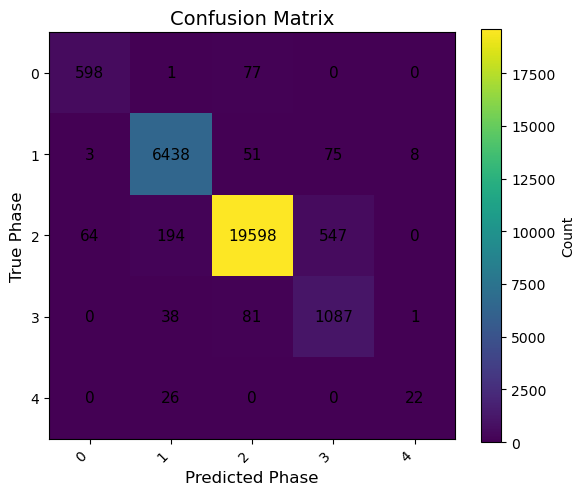

In [51]:
# ============================================================
# Cell 14: Confusion matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred, labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_title("Confusion Matrix", fontsize=14)
ax.set_xlabel("Predicted Phase", fontsize=12)
ax.set_ylabel("True Phase", fontsize=12)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Count")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(
            j,
            i,
            f"{cm[i, j]}",
            ha="center",
            va="center",
            fontsize=11
        )

fig.tight_layout()
fig.savefig("confusion_matrix_counts.png", dpi=300, bbox_inches="tight")
plt.show()

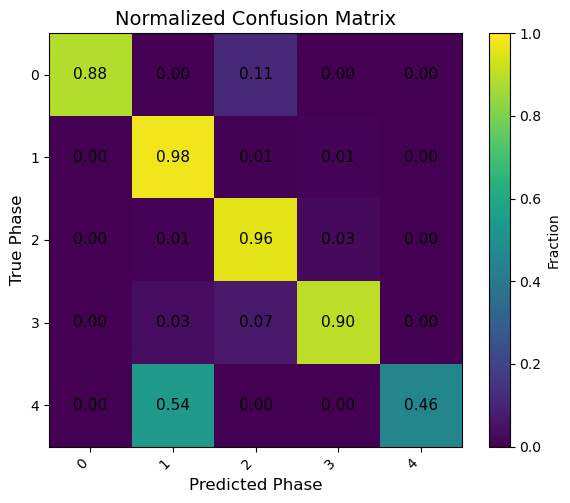

In [52]:
# ============================================================
# Cell 15: Normalized confusion matrix
# ============================================================

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm_norm, vmin=0, vmax=1)

ax.set_title("Normalized Confusion Matrix", fontsize=14)
ax.set_xlabel("Predicted Phase", fontsize=12)
ax.set_ylabel("True Phase", fontsize=12)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Fraction")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(
            j,
            i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=11
        )

fig.tight_layout()
fig.savefig("confusion_matrix_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

In [53]:
#Convert time-height grid to a machine-learning table
df = combined_ds.to_dataframe().reset_index()

print(df.shape)
df.head()

(1716480, 8)


,height,time,reflectivity,backscatter,cloud_phase_mplgr,velocity,spectral_width,liq
0,160.0,2015-06-10 00:00:00,NaN,NaN,0.0,NaN,NaN,0.001729
1,160.0,2015-06-10 00:00:30,NaN,0.343140,0.0,NaN,NaN,0.002157
2,160.0,2015-06-10 00:01:00,NaN,0.426462,0.0,NaN,NaN,0.001900
3,160.0,2015-06-10 00:01:30,NaN,0.296423,0.0,NaN,NaN,0.002250
4,160.0,2015-06-10 00:02:00,NaN,0.301030,0.0,NaN,NaN,0.003200


In [54]:
# Add profile/group ID
df["time"] = pd.to_datetime(df["time"])

# Each vertical profile gets one group ID
df["profile_id"] = df["time"].astype(str)

print(df[["time", "height", "profile_id"]].head())
print("Number of profiles:", df["profile_id"].nunique())

# What if multiple dates?
df["date_id"] = df["time"].dt.strftime("%Y%m%d")

                 time  height           profile_id
0 2015-06-10 00:00:00   160.0  2015-06-10 00:00:00
1 2015-06-10 00:00:30   160.0  2015-06-10 00:00:30
2 2015-06-10 00:01:00   160.0  2015-06-10 00:01:00
3 2015-06-10 00:01:30   160.0  2015-06-10 00:01:30
4 2015-06-10 00:02:00   160.0  2015-06-10 00:02:00
Number of profiles: 2880


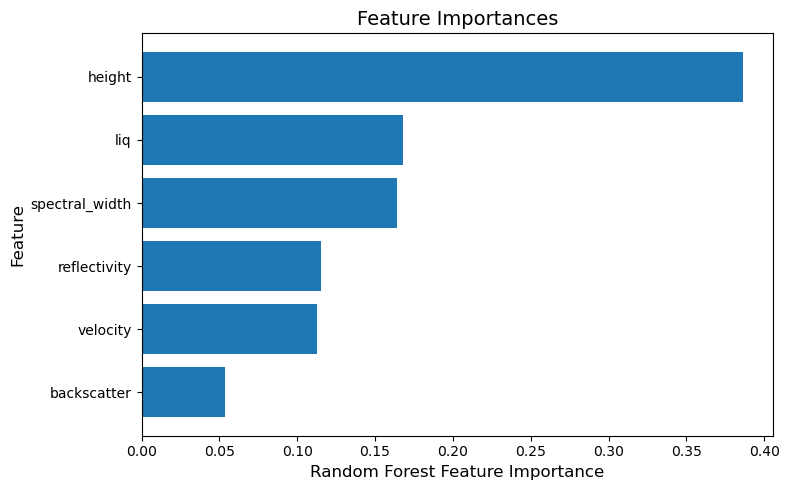

In [55]:
# Feature Importances
fi_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plot_df = fi_df.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(plot_df["feature"], plot_df["importance"])

ax.set_xlabel("Random Forest Feature Importance", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
ax.set_title("Feature Importances", fontsize=14)

fig.tight_layout()
fig.savefig("feature_importances.png", dpi=300, bbox_inches="tight")
plt.show()

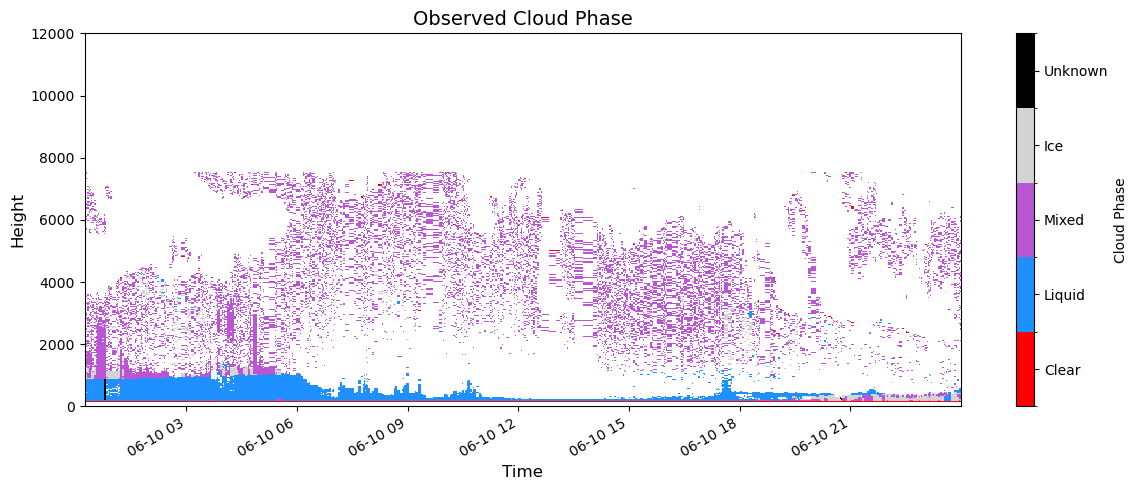

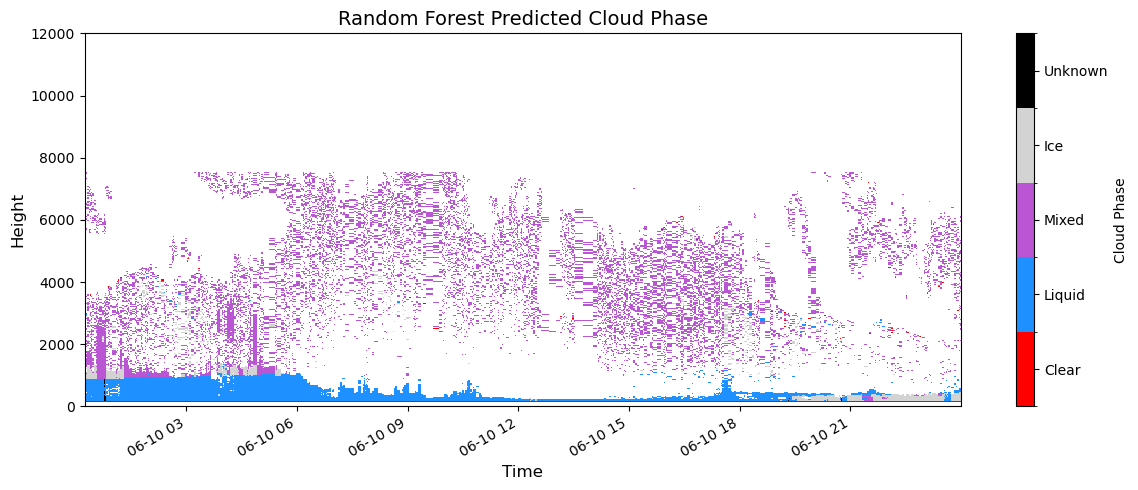

In [61]:
# ============================================================
# Cell: Phase curtain comparison
# ============================================================

from matplotlib.colors import ListedColormap, BoundaryNorm

# Make a copy of the test prediction DataFrame
plot_df = test_pred_df.copy()

# Make sure time is datetime
plot_df["time"] = pd.to_datetime(plot_df["time"])

# Observed and predicted phase columns
true_phase_col = "cloud_phase_mplgr"
pred_phase_col = "phase_pred"

# Make sure phase values are integers
plot_df[true_phase_col] = plot_df[true_phase_col].astype(int)
plot_df[pred_phase_col] = plot_df[pred_phase_col].astype(int)

# Define class names based on MPLGR cloud phase values
phase_label_names = {
    0: "Clear",
    1: "Liquid",
    2: "Mixed",
    3: "Ice",
    4: "Unknown"
}

class_values = sorted(phase_label_names.keys())
class_names = [phase_label_names[i] for i in class_values]

# Set fixed colors for each class
phase_colors = [
    "red",         # 0 Clear
    "dodgerblue",    # 1 Liquid
    "mediumorchid",  # 2 Mixed
    "lightgray",     # 3 Ice
    "black"          # 4 Unknown
]

# Discrete colormap and normalization
cmap = ListedColormap(phase_colors)
bounds = np.arange(-0.5, len(class_values) + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# Create observed phase grid
true_grid = plot_df.pivot_table(
    index="height",
    columns="time",
    values=true_phase_col,
    aggfunc="first"
)

# Create predicted phase grid
pred_grid = plot_df.pivot_table(
    index="height",
    columns="time",
    values=pred_phase_col,
    aggfunc="first"
)

# Sort height and time for clean plotting
true_grid = true_grid.sort_index().sort_index(axis=1)
pred_grid = pred_grid.sort_index().sort_index(axis=1)

# ============================================================
# Plot observed cloud phase
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.pcolormesh(
    true_grid.columns,
    true_grid.index.values,
    true_grid.values,
    shading="auto",
    cmap=cmap,
    norm=norm
)

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=class_values,
    boundaries=bounds,
    spacing="uniform"
)
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Cloud Phase")

ax.set_title("Observed Cloud Phase", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Height", fontsize=12)
ax.set_ylim(0, 12000)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_curtain_true.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Plot predicted cloud phase
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.pcolormesh(
    pred_grid.columns,
    pred_grid.index.values,
    pred_grid.values,
    shading="auto",
    cmap=cmap,
    norm=norm
)

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=class_values,
    boundaries=bounds,
    spacing="uniform"
)
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Cloud Phase")

ax.set_title("Random Forest Predicted Cloud Phase", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Height", fontsize=12)
ax.set_ylim(0, 12000)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("phase_curtain_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

Validation classification report:
              precision    recall  f1-score   support

       Clear       0.90      0.88      0.89       676
      Liquid       0.96      0.98      0.97      6575
         Ice       0.99      0.96      0.97     20403
       Mixed       0.64      0.90      0.75      1207
     Unknown       0.71      0.46      0.56        48

    accuracy                           0.96     28909
   macro avg       0.84      0.84      0.83     28909
weighted avg       0.97      0.96      0.96     28909



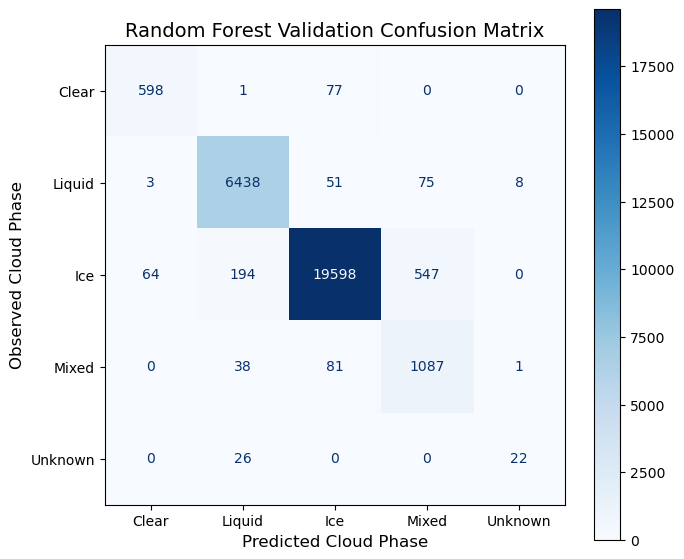

In [70]:
# Confusion Matrix for the Validation Dataset

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predict validation/test labels
y_val_pred = rf.predict(X_test)

# Define phase names
phase_label_names = {
    0: "Clear",
    1: "Liquid",
    2: "Ice",
    3: "Mixed",
    4: "Unknown"
}

class_values = sorted(phase_label_names.keys())
class_names = [phase_label_names[i] for i in class_values]

# Compute confusion matrix
cm = confusion_matrix(
    y_test,
    y_val_pred,
    labels=class_values
)

# Print classification report
print("Validation classification report:")
print(
    classification_report(
        y_test,
        y_val_pred,
        labels=class_values,
        target_names=class_names,
        zero_division=0
    )
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True,
    values_format="d"
)

ax.set_title("Random Forest Validation Confusion Matrix", fontsize=14)
ax.set_xlabel("Predicted Cloud Phase", fontsize=12)
ax.set_ylabel("Observed Cloud Phase", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

fig.tight_layout()
fig.savefig("validation_confusion_matrix_highres.png", dpi=300, bbox_inches="tight")
plt.show()

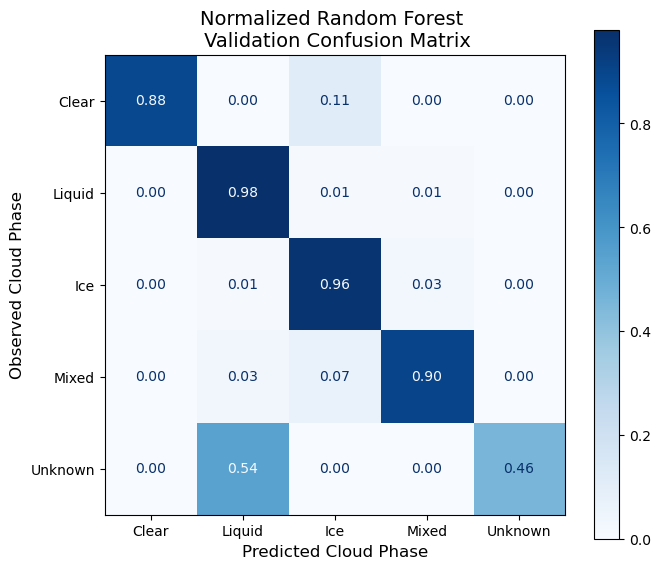

In [71]:
# ============================================================
# Cell: Normalized validation confusion matrix
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predict validation/test labels
y_val_pred = rf.predict(X_test)

# Define phase names
phase_label_names = {
    0: "Clear",
    1: "Liquid",
    2: "Ice",
    3: "Mixed",
    4: "Unknown"
}

class_values = sorted(phase_label_names.keys())
class_names = [phase_label_names[i] for i in class_values]

# Compute normalized confusion matrix
# normalize="true" normalizes each row by the observed class count
cm_norm = confusion_matrix(
    y_test,
    y_val_pred,
    labels=class_values,
    normalize="true"
)

# Plot normalized confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True,
    values_format=".2f"
)

ax.set_title("Normalized Random Forest \n Validation Confusion Matrix", fontsize=14)
ax.set_xlabel("Predicted Cloud Phase", fontsize=12)
ax.set_ylabel("Observed Cloud Phase", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

fig.tight_layout()
fig.savefig("validation_confusion_matrix_highres_normalized.png", dpi=300, bbox_inches="tight")
plt.show()